<a href="https://colab.research.google.com/github/awinarko-hue/Project_hue/blob/main/ECWSHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')
RAW = "/content/drive/MyDrive/Kuliah/TWh_Energy/Colab" # Simpan langsung di Drive Anda

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import io
import os
import time
import numpy as np
import pandas as pd
import requests
from IPython.display import display

START, END = 1990, 2024
COUNTRIES = ["IDN", "MYS", "THA", "VNM", "PHL", "SGP"]   # ubah/tambah sesuai kebutuhan

# Di Colab, direktori default adalah /content/
RAW = "/content/drive/MyDrive/Kuliah/TWh_Energy/Colab/data_raw3"
os.makedirs(RAW, exist_ok=True)

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
session = requests.Session()
session.headers.update(HEADERS)

print("Setup selesai. Folder data_raw2 dibuat di /content/")

Setup selesai. Folder data_raw2 dibuat di /content/


In [7]:
def http_get(url, params=None, tries=4, timeout=(10, 120)):
    last = None
    for i in range(tries):
        try:
            r = session.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r
        except Exception as e:
            last = e
            print(f"  -> Percobaan {i+1} gagal. Menunggu {2*(i+1)} detik...")
            time.sleep(2 * (i + 1))
    raise last

In [8]:
# 1) Target & variabel energi: OWID
OWID_URL = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
OWID_COLS = {
    "primary_energy_consumption": "y_primary_energy_twh",   # TARGET
    "coal_consumption": "coal_twh",
    "oil_consumption": "oil_twh",
    "gas_consumption": "gas_twh",
    "renewables_consumption": "renewables_twh",
    "electricity_generation": "elec_gen_twh",
}

def get_owid():
    r = http_get(OWID_URL)
    df = pd.read_csv(io.StringIO(r.text))
    df.to_csv(f"{RAW}/owid_energy_full.csv", index=False)
    df = df[df["iso_code"].isin(COUNTRIES) & df["year"].between(START, END)]
    keep = ["iso_code", "country", "year"] + list(OWID_COLS.keys())
    df = df[keep].rename(columns=OWID_COLS)
    print(f"[OK] OWID: {len(df)} baris")
    return df

# 2) Prediktor: World Bank WDI
WB_INDICATORS = {
    "NY.GDP.MKTP.KD": "gdp_const_usd",
    "NY.GDP.PCAP.PP.KD": "gdp_pc_ppp",
    "SP.POP.TOTL": "population",
    "SP.URB.TOTL.IN.ZS": "urban_pct",
    "NV.IND.TOTL.ZS": "industry_pct_gdp",
    "NV.IND.MANF.ZS": "manuf_pct_gdp",
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",
    "FP.CPI.TOTL.ZG": "inflation_pct",
    "PA.NUS.FCRF": "fx_lcu_per_usd",
    "EG.ELC.ACCS.ZS": "elec_access_pct",
    "EG.USE.ELEC.KH.PC": "elec_use_kwh_pc",
    "SP.POP.GROW": "pop_growth_pct",
}

def wb_indicator(code):
    ctry = "; ".join(COUNTRIES)
    url = f"https://api.worldbank.org/v2/country/{ctry}/indicator/{code}"
    rows, page = [], 1
    while True:
        r = http_get(url, params={"format": "json", "per_page": 5000,
                                  "date": f"{START}:{END}", "page": page})
        js = r.json()
        if not isinstance(js, list) or len(js) < 2 or js[1] is None:
            break
        meta, data = js
        rows += [(d["countryiso3code"], int(d["date"]), d["value"]) for d in data]
        if page >= meta.get("pages", 1):
            break
        page += 1
    df = pd.DataFrame(rows, columns=["iso_code", "year", code])
    return df

def get_worldbank():
    merged = None
    for code, name in WB_INDICATORS.items():
        try:
            df = wb_indicator(code).rename(columns={code: name})
            merged = df if merged is None else merged.merge(
                df, on=["iso_code", "year"], how="outer")
            print(f"[OK] WB {code} -> {name}")
        except Exception as e:
            print(f"[GAGAL] WB {code}: {type(e).__name__}")
    if merged is None:
        raise SystemExit("World Bank tidak bisa diakses dari jaringan ini.")
    merged.to_csv(f"{RAW}/worldbank_raw.csv", index=False)
    return merged

In [9]:
OWID_GRAPHER = {
    "crude-oil-prices": "brent_usd",
    "coal-prices": "coal_usd",
    "natural-gas-prices": "gas_usd",
}

def owid_grapher(slug):
    url = (f"https://ourworldindata.org/grapher/{slug}.csv"
           "?v=1&csvType=full&useColumnShortNames=true")
    r = http_get(url)
    df = pd.read_csv(io.StringIO(r.text))
    val_cols = [c for c in df.columns if c not in ("Entity", "Code", "Year")]
    if "Entity" in df and df["Entity"].nunique() > 1:
        world = df[df["Entity"].str.contains("World|Brent", case=False, na=False)]
        df = world if not world.empty else df[df["Entity"] == df["Entity"].iloc[0]]
    s = df.set_index("Year")[val_cols[0]]
    s = s[(s.index >= START) & (s.index <= END)]
    return s.groupby(level=0).mean()

def get_global_prices():
    series = {}
    for slug, name in OWID_GRAPHER.items():
        try:
            series[name] = owid_grapher(slug)
            print(f"[OK] OWID grapher {slug} -> {name}")
        except Exception as e:
            print(f"[LEWAT] OWID grapher {slug}: {type(e).__name__}")

    # Fallback jika ada data_integrated.csv yang di-upload ke Colab
    if os.path.exists("/content/data_integrated.csv"):
        m = pd.read_csv("/content/data_integrated.csv", index_col=0, parse_dates=True)
        m = m[m.index < "2026-09-01"]
        fallback = {"brent": "brent_usd", "coal_aus": "coal_aus_usd",
                    "lng_japan": "lng_japan_usd"}
        for col, name in fallback.items():
            if col in m:
                ann = m[col].groupby(m.index.year).mean()
                series[name if name not in series else name + "_t1"] = ann
                print(f"[INFO] {name} dari data_integrated.csv (mulai {m.index.min().year})")

    if not series:
        print("[PERINGATAN] Harga global tidak tersedia; panel dibuat tanpa kolom ini.")
        return pd.DataFrame(columns=["year"])

    g = pd.DataFrame(series)
    g.index.name = "year"
    g = g.reset_index()
    g.to_csv(f"{RAW}/global_prices_annual.csv", index=False)
    return g

In [10]:
def build_panel():
    owid = get_owid()
    wb = get_worldbank()
    glob = get_global_prices()
    panel = owid.merge(wb, on=["iso_code", "year"], how="left")
    if not glob.empty:
        panel = panel.merge(glob, on="year", how="left")
    panel = panel.sort_values(["iso_code", "year"]).reset_index(drop=True)
    panel["ln_gdp"] = np.log(panel["gdp_const_usd"])
    return panel

def missing_report(panel):
    rep = panel.groupby("iso_code").apply(lambda g: g.isna().sum()).drop(columns=["iso_code"], errors="ignore")
    rep.loc["TOTAL"] = panel.drop(columns=["iso_code"]).isna().sum()
    return rep

# --- Jalankan Proses ---
print("Memulai proses pengambilan dan penggabungan data...")
panel = build_panel()
panel.to_csv("/content/panel_asean_annual.csv", index=False)
rep = missing_report(panel)
rep.to_csv("/content/panel_missing_report.csv")

print("\n=== SELESAI ===")
print(f"Bentuk panel: {panel.shape}")
print("\nBaris per negara:\n", panel["iso_code"].value_counts().to_string())
print("\nKolom dengan nilai kosong terbanyak:")
print(rep.loc["TOTAL"].sort_values(ascending=False).head(10).to_string())

Memulai proses pengambilan dan penggabungan data...
[OK] OWID: 210 baris
[OK] WB NY.GDP.MKTP.KD -> gdp_const_usd
[OK] WB NY.GDP.PCAP.PP.KD -> gdp_pc_ppp
[OK] WB SP.POP.TOTL -> population
[OK] WB SP.URB.TOTL.IN.ZS -> urban_pct
[OK] WB NV.IND.TOTL.ZS -> industry_pct_gdp
[OK] WB NV.IND.MANF.ZS -> manuf_pct_gdp
[OK] WB NE.TRD.GNFS.ZS -> trade_pct_gdp
[OK] WB FP.CPI.TOTL.ZG -> inflation_pct
[OK] WB PA.NUS.FCRF -> fx_lcu_per_usd
[OK] WB EG.ELC.ACCS.ZS -> elec_access_pct
[OK] WB EG.USE.ELEC.KH.PC -> elec_use_kwh_pc
[OK] WB SP.POP.GROW -> pop_growth_pct
[LEWAT] OWID grapher crude-oil-prices: KeyError
[LEWAT] OWID grapher coal-prices: KeyError
[LEWAT] OWID grapher natural-gas-prices: KeyError
[PERINGATAN] Harga global tidak tersedia; panel dibuat tanpa kolom ini.

=== SELESAI ===
Bentuk panel: (210, 22)

Baris per negara:
 iso_code
IDN    35
MYS    35
PHL    35
SGP    35
THA    35
VNM    35

Kolom dengan nilai kosong terbanyak:
elec_access_pct         31
manuf_pct_gdp           25
inflation_pct

/tmp/ipykernel_2881/3727615883.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rep = panel.groupby("iso_code").apply(lambda g: g.isna().sum()).drop(columns=["iso_code"], errors="ignore")


In [11]:
# Preview 5 baris pertama
display(panel.head())

# Download file hasil ke komputer lokal Anda
from google.colab import files

print("\nMengunduh file CSV...")
files.download('/content/panel_asean_annual.csv')
files.download('/content/panel_missing_report.csv')

,iso_code,country,year,y_primary_energy_twh,coal_twh,oil_twh,gas_twh,renewables_twh,elec_gen_twh,gdp_const_usd,...,urban_pct,industry_pct_gdp,manuf_pct_gdp,trade_pct_gdp,inflation_pct,fx_lcu_per_usd,elec_access_pct,elec_use_kwh_pc,pop_growth_pct,ln_gdp
0,IDN,Indonesia,1990,600.179,39.788,366.263,171.730,21.558,33.115,2.699151e+11,...,30.594518,39.384940,19.893025,52.891861,7.819198,1842.813333,NaN,160.669338,1.814426,26.321373
1,IDN,Indonesia,1991,652.938,40.266,390.092,197.687,23.867,38.103,2.885716e+11,...,31.599195,41.204774,20.956438,54.839565,9.419068,1950.317500,48.900000,175.866313,1.770137,26.388209
2,IDN,Indonesia,1992,716.860,49.151,420.510,215.596,30.186,40.284,3.073216e+11,...,32.691499,39.979960,21.756442,57.427434,7.523510,2029.920833,66.696564,191.971592,1.733226,26.451160
3,IDN,Indonesia,1993,763.843,57.297,448.465,228.691,28.110,39.707,3.272864e+11,...,33.855542,39.680498,22.304951,50.523386,9.671911,2087.103867,55.430000,210.144408,1.701584,26.514102
4,IDN,Indonesia,1994,799.647,57.317,443.341,270.831,27.187,45.928,3.519637e+11,...,35.067201,40.642044,23.348038,51.877101,8.531998,2160.753675,62.800000,236.774847,1.685952,26.586794



Mengunduh file CSV...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import os
import json
import numpy as np
import pandas as pd
from IPython.display import display, FileLink

# ====== KONFIGURASI ======
# Sesuaikan path ini jika Anda menggunakan Google Drive
# Contoh: INPUT = "/content/drive/MyDrive/data_raw2/panel_asean_annual.csv"
INPUT = "/content/panel_asean_annual.csv"

MODE = "forecast"           # "forecast" (info <= t-1) atau "nowcast" (boleh prediktor tahun t)
USE_GLOBAL_PRICES = False   # harga global kosong 1990-2009 -> default dimatikan
ADD_COUNTRY_DUMMIES = True  # matikan bila memakai validasi leave-one-country-out
ADD_REGIME_DUMMIES = True   # dummy krisis 1998, krisis global 2009, COVID 2020
INTERP_LIMIT = 3            # maks. celah INTERIOR yang diinterpolasi (tahun)
ROLL_WINDOW = 3             # jendela rolling (tahun)
OUTLIER_THRESHOLD_PCT = 15.0
TARGET = "y_primary_energy_twh"
KEYS = ["iso_code", "year"]

DROP_ALWAYS = {
    "coal_twh":        "komponen target tahun berjalan -> leakage",
    "oil_twh":         "komponen target tahun berjalan -> leakage",
    "gas_twh":         "komponen target tahun berjalan -> leakage",
    "renewables_twh":  "komponen target tahun berjalan -> leakage",
    "elec_gen_twh":    "hampir tautologis dengan konsumsi energi -> leakage",
    "elec_use_kwh_pc": "bagian dari konsumsi energi + kosong di tahun terakhir",
    "elec_access_pct": "banyak kosong (MYS/THA/VNM) dan hampir jenuh di ASEAN-6",
    "manuf_pct_gdp":   "kosong besar (PHL, VNM); redundan dgn industry_pct_gdp",
    "pop_growth_pct":  "redundan dgn pertumbuhan ln_population",
    "gdp_const_usd":   "kolinier dgn gdp_pc_ppp x populasi",
    "ln_gdp":          "kolinier dgn ln_gdp_pc_ppp + ln_population",
}

GLOBAL_PRICE_COLS = ["brent_usd", "coal_aus_usd", "lng_japan_usd"]
LOG = []

def log(msg=""):
    print(msg)
    LOG.append(str(msg))

print("✅ Konfigurasi dimuat. Mode:", MODE)

✅ Konfigurasi dimuat. Mode: forecast


In [13]:
def load():
    if not os.path.exists(INPUT):
        raise FileNotFoundError(
            f"File {INPUT} tidak ditemukan. Upload file dari Tahap 2 atau mount Google Drive."
        )
    df = pd.read_csv(INPUT)
    df = df.sort_values(KEYS).reset_index(drop=True)
    assert not df.duplicated(KEYS).any(), "Ada duplikasi (iso_code, year)"
    assert df[TARGET].notna().all(), "Target memiliki nilai kosong -> periksa tahap 2"
    log(f"[MUAT] {df.shape[0]} baris, {df['iso_code'].nunique()} negara, "
        f"{df['year'].min()}-{df['year'].max()}")
    n = df.groupby("iso_code").size()
    log(f"[MUAT] baris per negara: {n.to_dict()}")
    return df

In [14]:
def clean(df):
    df = df.copy()

    # 2a. Transformasi yang memerlukan kolom mentah
    if "gdp_pc_ppp" in df:
        df["ln_gdp_pc_ppp"] = np.log(df["gdp_pc_ppp"])
    if "population" in df:
        df["ln_population"] = np.log(df["population"])
    if "fx_lcu_per_usd" in df:
        df["fx_depr_pct"] = df.groupby("iso_code")["fx_lcu_per_usd"].transform(
            lambda x: (x / x.shift(1) - 1) * 100)
    if USE_GLOBAL_PRICES:
        for c in GLOBAL_PRICE_COLS:
            if c in df:
                df[f"ln_{c}"] = np.log(df[c])

    # 2b. Buang kolom yang berisiko/tidak layak
    drop = dict(DROP_ALWAYS)
    for c in ["gdp_pc_ppp", "population", "fx_lcu_per_usd"]:
        drop[c] = "diganti versi transformasi (ln / persen perubahan)"
    if not USE_GLOBAL_PRICES:
        for c in GLOBAL_PRICE_COLS:
            drop[c] = "kosong 1990-2009 (USE_GLOBAL_PRICES=False)"
    else:
        for c in GLOBAL_PRICE_COLS:
            drop[c] = "diganti versi ln_"
    for c, why in drop.items():
        if c in df:
            df = df.drop(columns=c)
            log(f"[DROP] {c}: {why}")

    # 2c. Interpolasi celah INTERIOR per negara
    protect = set(KEYS + ["country", TARGET])
    for c in [c for c in df.columns if c not in protect and df[c].dtype.kind in "fi"]:
        before = df[c].isna().sum()
        df[c] = df.groupby("iso_code")[c].transform(
            lambda x: x.interpolate(method="linear", limit=INTERP_LIMIT,
                                    limit_area="inside"))
        filled = before - df[c].isna().sum()
        if filled:
            log(f"[INTERPOLASI] {c}: {filled} nilai diisi (celah interior, per negara)")

    # 2d. Sisa nilai kosong (awal/akhir seri) dilaporkan
    rest = df.drop(columns=["country"], errors="ignore").isna().sum()
    rest = rest[rest > 0]
    if len(rest):
        log("[SISA KOSONG] (awal/akhir seri; baris terkait akan gugur saat dropna fitur):")
        for c in rest.index:
            per = df[df[c].isna()].groupby("iso_code")["year"].agg(["min", "max", "count"])
            log("    " + c + ": " + "; ".join(
                f"{i} {r['min']}-{r['max']} ({r['count']})" for i, r in per.iterrows()))

    # 2e. Transformasi target
    g = df.groupby("iso_code")[TARGET]
    df["y_log"] = np.log(df[TARGET])
    df["y_growth_pct"] = g.transform(lambda x: (x / x.shift(1) - 1) * 100)

    # 2f. Laporan outlier target
    out = df[df["y_growth_pct"].abs() > OUTLIER_THRESHOLD_PCT][
        ["iso_code", "year", TARGET, "y_growth_pct"]]
    out.to_csv("/content/target_outliers.csv", index=False)
    log(f"[OUTLIER TARGET] {len(out)} tahun dengan |perubahan| > {OUTLIER_THRESHOLD_PCT}% "
        "-> lihat target_outliers.csv")
    for _, r in out.iterrows():
        log(f"    {r['iso_code']} {int(r['year'])}: {r['y_growth_pct']:+.1f}%")

    # 2g. Dummy rezim
    if ADD_REGIME_DUMMIES:
        df["regime_afc_1998"] = (df["year"] == 1998).astype(int)
        df["regime_gfc_2009"] = (df["year"] == 2009).astype(int)
        df["regime_covid_2020"] = (df["year"] == 2020).astype(int)
    return df

In [15]:
def build_features(df):
    df = df.copy()
    LEVEL_VARS = [c for c in ["ln_gdp_pc_ppp", "ln_population"] +
                  [f"ln_{c}" for c in GLOBAL_PRICE_COLS] if c in df]
    SHARE_VARS = [c for c in ["urban_pct", "industry_pct_gdp", "trade_pct_gdp"] if c in df]
    RATE_VARS = [c for c in ["inflation_pct", "fx_depr_pct"] if c in df]
    base = LEVEL_VARS + SHARE_VARS + RATE_VARS

    groups = {"lag": [], "roll": [], "growth": [], "ar": [], "contemp": [],
              "regime": [], "country": []}
    new = {}
    iso = df["iso_code"]

    for v in base:
        s = df.groupby("iso_code")[v]
        new[f"{v}_lag1"] = s.shift(1)
        new[f"{v}_lag2"] = s.shift(2)
        new[f"{v}_roll{ROLL_WINDOW}"] = s.transform(
            lambda x: x.shift(1).rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).mean())
        chg = s.diff()
        gname = f"{v}_growth1" if v in LEVEL_VARS else f"{v}_diff1"
        new[gname] = chg.groupby(iso).shift(1)
        groups["lag"] += [f"{v}_lag1", f"{v}_lag2"]
        groups["roll"].append(f"{v}_roll{ROLL_WINDOW}")
        groups["growth"].append(gname)
        if MODE == "nowcast":
            new[f"{v}_t0"] = df[v]
            new[f"{v}_chg0"] = chg
            groups["contemp"] += [f"{v}_t0", f"{v}_chg0"]

    # Fitur autoregresif dari target
    gy = df.groupby("iso_code")["y_log"]
    new["y_log_lag1"] = gy.shift(1)
    new["y_log_lag2"] = gy.shift(2)
    new[f"y_log_roll{ROLL_WINDOW}"] = gy.transform(
        lambda x: x.shift(1).rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).mean())
    new["y_growth_lag1"] = df.groupby("iso_code")["y_growth_pct"].shift(1)
    groups["ar"] = ["y_log_lag1", "y_log_lag2", f"y_log_roll{ROLL_WINDOW}", "y_growth_lag1"]

    df = pd.concat([df, pd.DataFrame(new, index=df.index)], axis=1)

    if ADD_REGIME_DUMMIES:
        groups["regime"] = [c for c in df.columns if c.startswith("regime_")]
    if ADD_COUNTRY_DUMMIES:
        d = pd.get_dummies(df["iso_code"], prefix="ctry", dtype=int)
        df = pd.concat([df, d], axis=1)
        groups["country"] = list(d.columns)
    return df, groups, base

In [16]:
def leakage_check(df_clean, groups_ref):
    """Mode forecast: perubahan besar pada data tahun terakhir TIDAK BOLEH
    mengubah fitur pada baris tahun terakhir (semua fitur memakai shift >= 1)."""
    if MODE != "forecast":
        log("[CEK LEAKAGE] dilewati (mode nowcast memang memakai data tahun t)")
        return
    a, ga, base = build_features(df_clean)
    d2 = df_clean.copy()
    last = d2["year"] == d2["year"].max()
    cols = [c for c in base + [TARGET, "y_log", "y_growth_pct"] if c in d2]
    d2.loc[last, cols] = d2.loc[last, cols] * 1000 + 12345
    b, gb, _ = build_features(d2)
    feats = [c for k in ["lag", "roll", "growth", "ar"] for c in ga[k]]
    m = a["year"] == a["year"].max()
    same = np.allclose(a.loc[m, feats].to_numpy(dtype=float),
                       b.loc[m, feats].to_numpy(dtype=float), equal_nan=True)
    log(f"[CEK LEAKAGE] fitur tahun terakhir tidak bergantung pada data tahun itu: "
        f"{'LOLOS ✅' if same else 'GAGAL ❌'}")
    assert same, "Terdeteksi leakage pada pembuatan fitur!"

In [17]:
print("🚀 Memulai pipeline Tahap 3...\n")
raw = load()
clean_df = clean(raw)
clean_df.to_csv("/content/panel_clean.csv", index=False)

feat_df, groups, base = build_features(clean_df)
leakage_check(clean_df, groups)

# Korelasi antar variabel dasar (pooled)
corr = clean_df[base].corr().abs()
pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(base)
         for b in base[i + 1:] if corr.loc[a, b] > 0.9]
pd.DataFrame(pairs, columns=["var1", "var2", "abs_corr"]).to_csv(
    "/content/high_corr_pairs.csv", index=False)
log(f"[KORELASI] {len(pairs)} pasangan variabel dasar |r| > 0.9 (lihat high_corr_pairs.csv)")
for a, b, r in pairs:
    log(f"    {a} ~ {b}: {r:.2f}")

# Buang baris yang fiturnya belum terbentuk (tahun awal per negara)
model_feats = [c for k in ["lag", "roll", "growth", "ar", "contemp"] for c in groups[k]]
before = feat_df.groupby("iso_code").size()
final = feat_df.dropna(subset=model_feats).reset_index(drop=True)
after = final.groupby("iso_code").size()
log("[DROPNA FITUR] baris per negara sebelum -> sesudah: " +
    ", ".join(f"{i}: {before[i]}->{after.get(i, 0)}" for i in before.index))

id_cols = KEYS + (["country"] if "country" in final else [])
tgt_cols = [TARGET, "y_log", "y_growth_pct"]
all_feats = model_feats + groups["regime"] + groups["country"]
final[id_cols + tgt_cols + all_feats].to_csv("/content/panel_features.csv", index=False)

exog = [c for k in ["lag", "roll", "growth", "contemp", "regime", "country"]
        for c in groups[k]]
groups_out = dict(groups)
groups_out["targets"] = tgt_cols
groups_out["set_exog_only"] = exog
groups_out["set_with_ar"] = exog + groups["ar"]
with open("/content/feature_groups.json", "w", encoding="utf-8") as f:
    json.dump(groups_out, f, indent=2)

log("")
log(f"[SELESAI] panel_features.csv: {final.shape[0]} baris x "
    f"{len(all_feats)} fitur (mode={MODE})")
log(f"          set_exog_only: {len(exog)} fitur | set_with_ar: {len(exog) + len(groups['ar'])} fitur")
log(f"          rasio baris/fitur (with_ar): {final.shape[0] / (len(exog) + len(groups['ar'])):.1f}")

with open("/content/cleaning_log.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(LOG))

# Simpan ke variabel global agar bisa dipakai di cell berikutnya
panel_features = final

🚀 Memulai pipeline Tahap 3...

[MUAT] 210 baris, 6 negara, 1990-2024
[MUAT] baris per negara: {'IDN': 35, 'MYS': 35, 'PHL': 35, 'SGP': 35, 'THA': 35, 'VNM': 35}
[DROP] coal_twh: komponen target tahun berjalan -> leakage
[DROP] oil_twh: komponen target tahun berjalan -> leakage
[DROP] gas_twh: komponen target tahun berjalan -> leakage
[DROP] renewables_twh: komponen target tahun berjalan -> leakage
[DROP] elec_gen_twh: hampir tautologis dengan konsumsi energi -> leakage
[DROP] elec_use_kwh_pc: bagian dari konsumsi energi + kosong di tahun terakhir
[DROP] elec_access_pct: banyak kosong (MYS/THA/VNM) dan hampir jenuh di ASEAN-6
[DROP] manuf_pct_gdp: kosong besar (PHL, VNM); redundan dgn industry_pct_gdp
[DROP] pop_growth_pct: redundan dgn pertumbuhan ln_population
[DROP] gdp_const_usd: kolinier dgn gdp_pc_ppp x populasi
[DROP] ln_gdp: kolinier dgn ln_gdp_pc_ppp + ln_population
[DROP] gdp_pc_ppp: diganti versi transformasi (ln / persen perubahan)
[DROP] population: diganti versi transforma

In [18]:
print("\n📊 Preview 5 baris pertama dari panel_features.csv:")
display(panel_features.head())

print("\n📋 Ringkasan kolom:")
print(f"  - Total kolom : {panel_features.shape[1]}")
print(f"  - Total baris : {panel_features.shape[0]}")
print(f"  - Negara      : {sorted(panel_features['iso_code'].unique())}")
print(f"  - Rentang thn : {panel_features['year'].min()} - {panel_features['year'].max()}")

# Download semua file hasil ke komputer lokal
from google.colab import files

OUTPUT_FILES = [
    "/content/panel_clean.csv",
    "/content/panel_features.csv",
    "/content/feature_groups.json",
    "/content/target_outliers.csv",
    "/content/high_corr_pairs.csv",
    "/content/cleaning_log.txt",
]

print("\n⬇️ Mengunduh file hasil...")
for fp in OUTPUT_FILES:
    if os.path.exists(fp):
        files.download(fp)


📊 Preview 5 baris pertama dari panel_features.csv:


,iso_code,country,year,y_primary_energy_twh,urban_pct,industry_pct_gdp,trade_pct_gdp,inflation_pct,ln_gdp_pc_ppp,ln_population,...,y_log_lag1,y_log_lag2,y_log_roll3,y_growth_lag1,ctry_IDN,ctry_MYS,ctry_PHL,ctry_SGP,ctry_THA,ctry_VNM
0,IDN,Indonesia,1994,799.647,35.067201,40.642044,51.877101,8.531998,8.687988,19.096640,...,6.638362,6.574881,6.564908,6.553999,1,0,0,0,0,0
1,IDN,Indonesia,1995,870.284,36.302351,41.800837,53.958590,9.420303,8.750356,19.113268,...,6.684170,6.638362,6.632471,4.687351,1,0,0,0,0,0
2,IDN,Indonesia,1996,933.146,37.536869,43.455784,52.264744,7.973281,8.809177,19.129723,...,6.768820,6.684170,6.697117,8.833523,1,0,0,0,0,0
3,IDN,Indonesia,1997,1012.695,38.746631,44.328957,55.993859,6.226152,8.838842,19.145986,...,6.838562,6.768820,6.763851,7.223159,1,0,0,0,0,0
4,IDN,Indonesia,1998,995.569,39.907514,45.227771,96.186192,58.451041,8.682315,19.161793,...,6.920370,6.838562,6.842584,8.524818,1,0,0,0,0,0



📋 Ringkasan kolom:
  - Total kolom : 54
  - Total baris : 181
  - Negara      : ['IDN', 'MYS', 'PHL', 'SGP', 'THA', 'VNM']
  - Rentang thn : 1994 - 2024

⬇️ Mengunduh file hasil...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Install library yang belum tersedia default di Colab
!pip install -q shap xgboost scikit-learn matplotlib pandas numpy
print("✅ Library terinstal. Silakan lanjut ke cell berikutnya.")

✅ Library terinstal. Silakan lanjut ke cell berikutnya.


In [20]:
import json
import os
import re
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

# ====== KONFIGURASI ======
# Sesuaikan path jika Anda menyimpan di Google Drive
INPUT_DIR = "/content"
OUT = "/content/hasil_modeling"
os.makedirs(OUT, exist_ok=True)

TEST_START = 2015          # tahun uji pertama (walk-forward 1 tahun per fold)
SEED = 42
QUICK_MODE = False         # True = jalankan cepat untuk uji (N_EST kecil)
N_EST = 100 if QUICK_MODE else int(os.environ.get("N_EST", 500))

SELECT_CUM = 0.90          # ambil fitur sampai kumulatif |SHAP| >= 90%
K_MIN, K_MAX = 5, 15

KEYS = ["iso_code", "year"]
TARGET_LOG = "y_log"
TARGET_LEVEL = "y_primary_energy_twh"
FOCUS_COUNTRY = "IDN"

print(f"✅ Konfigurasi dimuat. QUICK_MODE={QUICK_MODE}, N_EST={N_EST}")
print(f"   Output folder: {OUT}")

✅ Konfigurasi dimuat. QUICK_MODE=False, N_EST=500
   Output folder: /content/hasil_modeling


In [21]:
def load():
    feats_df = pd.read_csv(f"{INPUT_DIR}/panel_features.csv")
    clean = pd.read_csv(f"{INPUT_DIR}/panel_clean.csv")
    with open(f"{INPUT_DIR}/feature_groups.json", encoding="utf-8") as f:
        groups = json.load(f)
    sets = {
        "exog_only": [c for c in groups["set_exog_only"] if c in feats_df],
        "with_ar":   [c for c in groups["set_with_ar"]   if c in feats_df],
    }
    print(f"[MUAT] panel_features: {feats_df.shape}, panel_clean: {clean.shape}")
    print(f"       exog_only: {len(sets['exog_only'])} fitur | with_ar: {len(sets['with_ar'])} fitur")
    return feats_df, clean, sets

feats_df, clean, sets = load()

[MUAT] panel_features: (181, 47), panel_clean: (210, 16)
       exog_only: 37 fitur | with_ar: 41 fitur


In [22]:
def make_models():
    models = {
        "RF": lambda: RandomForestRegressor(
            n_estimators=N_EST, min_samples_leaf=2, max_features=0.5,
            n_jobs=-1, random_state=SEED),
        "ET": lambda: ExtraTreesRegressor(
            n_estimators=N_EST, min_samples_leaf=2, max_features=0.7,
            n_jobs=-1, random_state=SEED),
    }
    try:
        from xgboost import XGBRegressor
        models["XGB"] = lambda: XGBRegressor(
            n_estimators=min(N_EST, 400), max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7, reg_lambda=1.0,
            n_jobs=-1, random_state=SEED, verbosity=0)
        print(f"[MODEL] RF, ET, XGB siap (N_EST={N_EST})")
    except ImportError:
        print("[PERINGATAN] xgboost belum terpasang. Lanjut dengan RF & ET saja.")
    return models

models = make_models()

[MODEL] RF, ET, XGB siap (N_EST=500)


In [23]:
SUFFIX = re.compile(r"(lag\d+|roll\d+|growth\d+|diff\d+|t0|chg0)$")
DUMMY_PREFIX = ("ctry", "regime_")

def build_extra_pool(clean):
    """Fitur tambahan untuk tahap re-engineering: lag3, rolling5, perubahan 2-tahun.
    Semuanya hanya memakai informasi <= t-1 (per negara)."""
    c = clean.sort_values(KEYS).reset_index(drop=True)
    bases = [b for b in ["ln_gdp_pc_ppp", "ln_population", "urban_pct",
                         "industry_pct_gdp", "trade_pct_gdp", "inflation_pct",
                         "fx_depr_pct", "ln_brent_usd", "ln_coal_aus_usd",
                         "ln_lng_japan_usd"] if b in c]
    new = {}
    for v in bases:
        s = c.groupby("iso_code")[v]
        new[f"{v}_lag3"] = s.shift(3)
        new[f"{v}_roll5"] = s.transform(
            lambda x: x.shift(1).rolling(5, min_periods=3).mean())
        new[f"{v}_chg2"] = s.diff(2).groupby(c["iso_code"]).shift(1)
    gy = c.groupby("iso_code")[TARGET_LOG]
    new["y_log_lag3"] = gy.shift(3)
    new["y_log_roll5"] = gy.transform(
        lambda x: x.shift(1).rolling(5, min_periods=3).mean())
    new["y_chg2_lag1"] = gy.diff(2).groupby(c["iso_code"]).shift(1)
    pool = pd.concat([c[KEYS], pd.DataFrame(new, index=c.index)], axis=1)
    return pool, bases

def extras_for(selected, bases):
    cols = []
    for f in selected:
        b = SUFFIX.sub("", f)
        if b in bases:
            cols += [f"{b}_lag3", f"{b}_roll5", f"{b}_chg2"]
        elif f.startswith("y_"):
            cols += ["y_log_lag3", "y_log_roll5", "y_chg2_lag1"]
    return list(dict.fromkeys(cols))

def interaction_pairs(selected, k=3):
    top = [f for f in selected if not f.startswith(DUMMY_PREFIX)][:k]
    return list(combinations(top, 2))

def assemble(frame, selected, extras, pairs):
    avail = [c for c in selected + extras if c in frame.columns]
    X = frame[avail].copy()
    for a, b in pairs:
        if a in frame.columns and b in frame.columns:
            X[f"{a}x{b}"] = frame[a] * frame[b]
    return X

def impute(Xtr, Xte):
    imp = SimpleImputer(strategy="median")
    tr = pd.DataFrame(imp.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
    te = pd.DataFrame(imp.transform(Xte), columns=Xte.columns, index=Xte.index)
    return tr, te

# Bangun pool fitur tambahan
pool, bases = build_extra_pool(clean)
df = feats_df.merge(pool, on=KEYS, how="left")
print(f"[POOL] Fitur tambahan ditambahkan. Shape akhir: {df.shape}")

[POOL] Fitur tambahan ditambahkan. Shape akhir: (181, 71)


In [24]:
def shap_shares(fitted, X):
    """Rata-rata |SHAP| ternormalisasi per model -> DataFrame (fitur x model)."""
    cols = {}
    for name, m in fitted.items():
        sv = shap.TreeExplainer(m).shap_values(X, check_additivity=False)
        imp = np.abs(sv).mean(axis=0)
        cols[name] = imp / imp.sum() if imp.sum() > 0 else imp
    return pd.DataFrame(cols, index=X.columns)

def shap_select(shares):
    avg = shares.mean(axis=1).sort_values(ascending=False)
    cum = avg.cumsum() / avg.sum()
    k = int(np.searchsorted(cum.values, SELECT_CUM) + 1)
    k = min(max(k, K_MIN), K_MAX, len(avg))
    return list(avg.index[:k]), avg

print("✅ Fungsi SHAP & seleksi siap.")

✅ Fungsi SHAP & seleksi siap.


In [25]:
def pred_rows(te, preds, model, stage, fset):
    return pd.DataFrame({
        "iso_code": te["iso_code"].values, "year": te["year"].values,
        "y_true_log": te[TARGET_LOG].values, "pred_log": preds,
        "model": model, "stage": stage, "feat_set": fset
    })

def fit_all(models, Xtr, ytr):
    fitted = {}
    for name, mk in models.items():
        m = mk()
        m.fit(Xtr, ytr)
        fitted[name] = m
    return fitted

def run_fold(df, feats, fset, test_year, models, bases):
    tr = df[df["year"] < test_year]
    te = df[df["year"] == test_year]
    if te.empty or len(tr) < 50:
        return [], None
    ytr = tr[TARGET_LOG]
    rows = []

    # --- Stage A: semua fitur
    avail_a = [c for c in feats if c in tr.columns]
    Xtr, Xte = impute(tr[avail_a], te[avail_a])
    fitted = fit_all(models, Xtr, ytr)
    for n, m in fitted.items():
        rows.append(pred_rows(te, m.predict(Xte), n, "A_all_features", fset))

    # --- SHAP + seleksi (hanya data latih fold ini -> anti-leakage)
    sel, _ = shap_select(shap_shares(fitted, Xtr))

    # --- Stage B: fitur terpilih
    avail_b = [c for c in sel if c in tr.columns]
    Xtr_b, Xte_b = impute(tr[avail_b], te[avail_b])
    for n, m in fit_all(models, Xtr_b, ytr).items():
        rows.append(pred_rows(te, m.predict(Xte_b), n, "B_shap_selected", fset))

    # --- Stage C: re-engineering
    extras = extras_for(sel, bases)
    pairs = interaction_pairs(sel)
    Xtr_c = assemble(tr, sel, extras, pairs)
    Xte_c = assemble(te, sel, extras, pairs)
    Xtr_c, Xte_c = impute(Xtr_c, Xte_c)
    for n, m in fit_all(models, Xtr_c, ytr).items():
        rows.append(pred_rows(te, m.predict(Xte_c), n, "C_reengineered", fset))

    return rows, sel

def naive_rows(df, test_years):
    te = df[df["year"].isin(test_years)]
    r1 = pred_rows(te, te["y_log_lag1"].values, "Naive_lag1", "Baseline", "n/a")
    drift = te["y_log_lag1"] + (te["y_log_lag1"] - te["y_log_lag2"])
    r2 = pred_rows(te, drift.values, "Naive_drift", "Baseline", "n/a")
    return [r1, r2]

print("✅ Fungsi walk-forward fold siap.")

✅ Fungsi walk-forward fold siap.


In [26]:
def metrics(g):
    y, p = np.exp(g["y_true_log"]), np.exp(g["pred_log"])
    return pd.Series({
        "n": len(g),
        "MAE": np.mean(np.abs(y - p)),
        "RMSE": np.sqrt(np.mean((y - p) ** 2)),
        "MAPE": np.mean(np.abs((y - p) / y)) * 100,
        "R2": r2_score(y, p) if len(g) > 1 else np.nan,
        "R2_log": r2_score(g["y_true_log"], g["pred_log"]) if len(g) > 1 else np.nan,
    })

def summarize(pred):
    keys = ["feat_set", "stage", "model"]
    scopes = {
        "ALL_countries": pred,
        f"{FOCUS_COUNTRY}_only": pred[pred["iso_code"] == FOCUS_COUNTRY],
        f"{FOCUS_COUNTRY}_excl2022": pred[(pred["iso_code"] == FOCUS_COUNTRY)
                                          & (pred["year"] != 2022)],
    }
    out = []
    for name, d in scopes.items():
        if d.empty:
            continue
        m = d.groupby(keys).apply(metrics).reset_index()
        m.insert(0, "scope", name)
        out.append(m)
    return pd.concat(out, ignore_index=True)

def final_shap(df, feats, fset, models, bases):
    ytr = df[TARGET_LOG]
    avail = [c for c in feats if c in df.columns]
    Xa, _ = impute(df[avail], df[avail])
    fitted = fit_all(models, Xa, ytr)
    sel, _ = shap_select(shap_shares(fitted, Xa))

    extras, pairs = extras_for(sel, bases), interaction_pairs(sel)
    Xc_full = assemble(df, sel, extras, pairs)
    Xc, _ = impute(Xc_full, Xc_full)
    fitted_c = fit_all(models, Xc, ytr)

    shares = shap_shares(fitted_c, Xc)
    shares["mean_share"] = shares.mean(axis=1)
    shares = shares.sort_values("mean_share", ascending=False)
    shares.to_csv(f"{OUT}/shap_importance_final_{fset}.csv")

    # Bar chart
    top = shares.head(15).iloc[::-1]
    plt.figure(figsize=(8, 5.5))
    plt.barh(top.index, top["mean_share"])
    plt.xlabel("Rata-rata |SHAP| ternormalisasi")
    plt.title(f"Feature importance model final ({fset})")
    plt.tight_layout()
    plt.savefig(f"{OUT}/fig_shap_bar_{fset}.png", dpi=160)
    plt.close()

    # Beeswarm
    key = "XGB" if "XGB" in fitted_c else "RF"
    sv = shap.TreeExplainer(fitted_c[key]).shap_values(Xc, check_additivity=False)
    plt.figure()
    shap.summary_plot(sv, Xc, max_display=15, show=False)
    plt.title(f"SHAP beeswarm ({key}, {fset})")
    plt.tight_layout()
    plt.savefig(f"{OUT}/fig_shap_beeswarm_{fset}.png", dpi=160)
    plt.close()
    return sel

def plot_focus(pred, feats_df):
    hist = feats_df[feats_df["iso_code"] == FOCUS_COUNTRY]
    plt.figure(figsize=(9, 5))
    plt.plot(hist["year"], hist[TARGET_LEVEL], color="black", label="Aktual")
    for fset, ls in [("with_ar", "--"), ("exog_only", ":")]:
        d = pred[(pred["iso_code"] == FOCUS_COUNTRY)
                 & (pred["model"] == "ENS_MEAN")
                 & (pred["stage"] == "C_reengineered")
                 & (pred["feat_set"] == fset)]
        if not d.empty:
            plt.plot(d["year"], np.exp(d["pred_log"]), ls, marker="o",
                     label=f"Prediksi final ({fset})")
    nv = pred[(pred["iso_code"] == FOCUS_COUNTRY) & (pred["model"] == "Naive_lag1")]
    if not nv.empty:
        plt.plot(nv["year"], np.exp(nv["pred_log"]), color="gray", alpha=.6,
                 label="Naive lag-1")
    plt.ylabel("Konsumsi energi primer (TWh)")
    plt.title(f"{FOCUS_COUNTRY}: aktual vs prediksi walk-forward")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUT}/fig_pred_vs_actual_{FOCUS_COUNTRY}.png", dpi=160)
    plt.show()
    plt.close()

print("✅ Fungsi metrik & plotting siap.")

✅ Fungsi metrik & plotting siap.



🚀 Data: 181 baris | model: ['RF', 'ET', 'XGB']
   Tahun uji: 2015-2024 (10 fold)
   set 'exog_only': 37 fitur
   set 'with_ar': 41 fitur
  [exog_only] fold 2015 selesai (15 fitur terpilih)
  [exog_only] fold 2016 selesai (15 fitur terpilih)
  [exog_only] fold 2017 selesai (15 fitur terpilih)
  [exog_only] fold 2018 selesai (15 fitur terpilih)
  [exog_only] fold 2019 selesai (15 fitur terpilih)
  [exog_only] fold 2020 selesai (15 fitur terpilih)
  [exog_only] fold 2021 selesai (15 fitur terpilih)
  [exog_only] fold 2022 selesai (15 fitur terpilih)
  [exog_only] fold 2023 selesai (15 fitur terpilih)
  [exog_only] fold 2024 selesai (15 fitur terpilih)
  [with_ar] fold 2015 selesai (8 fitur terpilih)
  [with_ar] fold 2016 selesai (8 fitur terpilih)
  [with_ar] fold 2017 selesai (7 fitur terpilih)
  [with_ar] fold 2018 selesai (7 fitur terpilih)
  [with_ar] fold 2019 selesai (7 fitur terpilih)
  [with_ar] fold 2020 selesai (7 fitur terpilih)
  [with_ar] fold 2021 selesai (8 fitur terpilih)

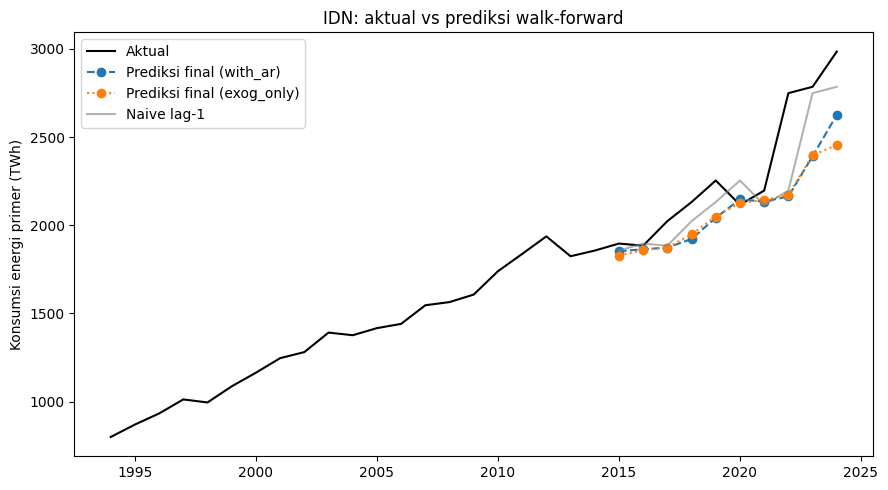


=== Ringkasan (semua negara, out-of-sample, satuan TWh) ===
 feat_set           stage       model    n     MAE    RMSE   MAPE    R2  R2_log
exog_only  A_all_features    ENS_MEAN 60.0 145.351 192.228 10.963 0.884   0.906
exog_only B_shap_selected    ENS_MEAN 60.0 115.927 158.897  8.777 0.921   0.940
exog_only  C_reengineered    ENS_MEAN 60.0 114.892 157.169  8.924 0.923   0.940
      n/a        Baseline Naive_drift 60.0  64.852 126.127  4.374 0.950   0.979
      n/a        Baseline  Naive_lag1 60.0  60.496  97.451  4.766 0.970   0.980
  with_ar  A_all_features    ENS_MEAN 60.0  72.623 135.371  5.030 0.943   0.974
  with_ar B_shap_selected    ENS_MEAN 60.0  67.997 119.639  4.871 0.955   0.977
  with_ar  C_reengineered    ENS_MEAN 60.0  69.944 122.530  4.999 0.953   0.975

✅ Semua keluaran ada di folder '/content/hasil_modeling/'.


In [27]:
test_years = sorted(y for y in df["year"].unique() if y >= TEST_START)
print(f"\n🚀 Data: {df.shape[0]} baris | model: {list(models)}")
print(f"   Tahun uji: {test_years[0]}-{test_years[-1]} ({len(test_years)} fold)")
for k, v in sets.items():
    print(f"   set '{k}': {len(v)} fitur")

all_rows, sel_records = naive_rows(df, test_years), []

for fset, feats in sets.items():
    for ty in test_years:
        rows, sel = run_fold(df, feats, fset, ty, models, bases)
        all_rows += rows
        if sel is not None:
            sel_records.append({"feat_set": fset, "year": ty, "selected": sel})
        print(f"  [{fset}] fold {ty} selesai ({len(sel) if sel else 0} fitur terpilih)")

pred = pd.concat(all_rows, ignore_index=True)

# Ensemble rata-rata
ens = (pred[pred["model"].isin(models.keys())]
       .groupby(["iso_code", "year", "y_true_log", "stage", "feat_set"],
                as_index=False)["pred_log"].mean())
ens["model"] = "ENS_MEAN"
pred = pd.concat([pred, ens[pred.columns]], ignore_index=True)
pred.to_csv(f"{OUT}/predictions_oos.csv", index=False)

res = summarize(pred)
res.to_csv(f"{OUT}/results_metrics.csv", index=False)

# Frekuensi seleksi fitur antar fold
rec = [(r["feat_set"], f) for r in sel_records for f in r["selected"]]
freq = (pd.DataFrame(rec, columns=["feat_set", "feature"])
        .value_counts().rename("n_folds").reset_index())
freq["share_of_folds"] = freq["n_folds"] / len(test_years)
freq.to_csv(f"{OUT}/feature_selection_frequency.csv", index=False)

# Model final pada seluruh data + SHAP + grafik
for fset, feats in sets.items():
    sel = final_shap(df, feats, fset, models, bases)
    print(f"[FINAL {fset}] fitur terpilih: {sel}")

plot_focus(pred, df)

# Ringkasan
show = res[(res["scope"] == "ALL_countries")
           & (res["model"].isin(["ENS_MEAN", "Naive_lag1", "Naive_drift"]))]
print("\n=== Ringkasan (semua negara, out-of-sample, satuan TWh) ===")
print(show[["feat_set", "stage", "model", "n", "MAE", "RMSE", "MAPE", "R2", "R2_log"]]
      .round(3).to_string(index=False))
print(f"\n✅ Semua keluaran ada di folder '{OUT}/'.")


📈 Grafik aktual vs prediksi untuk IDN :


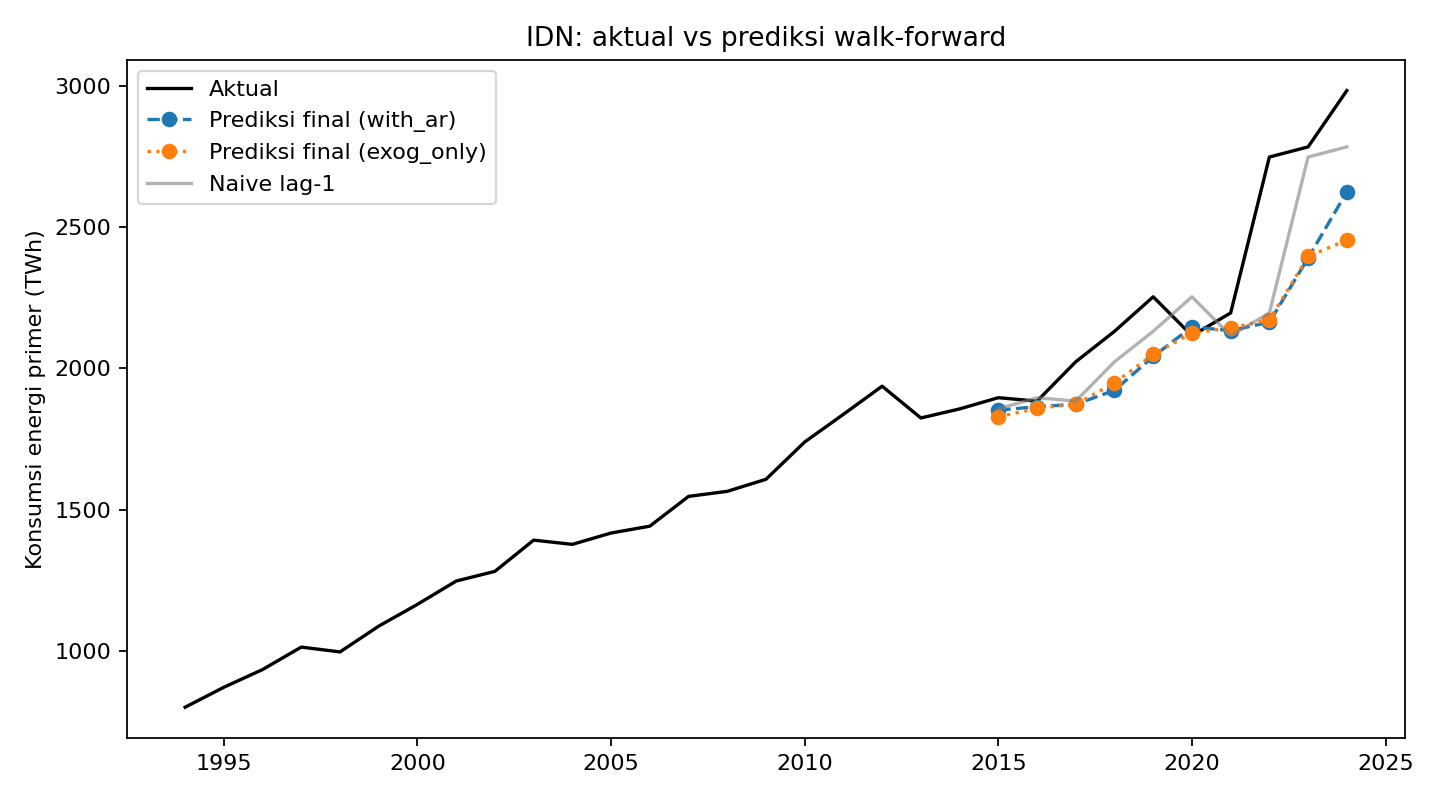


📊 SHAP importance (exog_only):


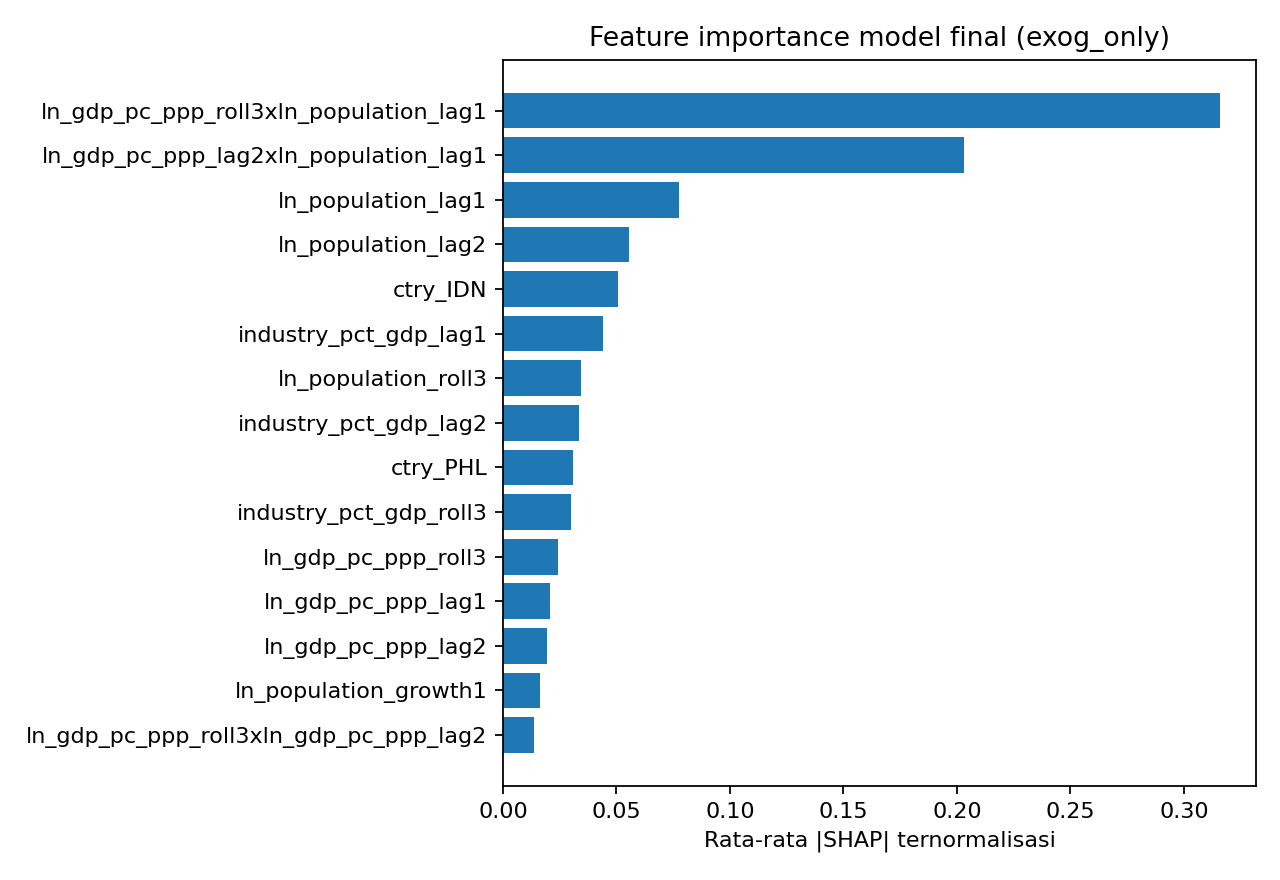


⬇️ Mengunduh semua file hasil...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from IPython.display import Image, display, FileLink
from google.colab import files

# Tampilkan grafik utama
print("\n📈 Grafik aktual vs prediksi untuk", FOCUS_COUNTRY, ":")
display(Image(filename=f"{OUT}/fig_pred_vs_actual_{FOCUS_COUNTRY}.png"))

print("\n📊 SHAP importance (exog_only):")
display(Image(filename=f"{OUT}/fig_shap_bar_exog_only.png"))

# Daftar file hasil
OUTPUT_FILES = [
    f"{OUT}/results_metrics.csv",
    f"{OUT}/predictions_oos.csv",
    f"{OUT}/feature_selection_frequency.csv",
    f"{OUT}/shap_importance_final_exog_only.csv",
    f"{OUT}/shap_importance_final_with_ar.csv",
    f"{OUT}/fig_shap_bar_exog_only.png",
    f"{OUT}/fig_shap_bar_with_ar.png",
    f"{OUT}/fig_shap_beeswarm_exog_only.png",
    f"{OUT}/fig_shap_beeswarm_with_ar.png",
    f"{OUT}/fig_pred_vs_actual_{FOCUS_COUNTRY}.png",
]

print("\n⬇️ Mengunduh semua file hasil...")
for fp in OUTPUT_FILES:
    if os.path.exists(fp):
        files.download(fp)